<a href="https://colab.research.google.com/github/Raksh1707/Datamining_project/blob/main/mining8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [5]:
from google.colab import files
uploaded = files.upload()

Saving miningcreditcard.csv to miningcreditcard.csv


In [6]:
df = pd.read_csv("miningcreditcard.csv")

print("First 5 Records")
print(df.head())

print("\nShape")
print(df.shape)

print("\nInformation")
print(df.info())

First 5 Records
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26     

In [7]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64



Transaction Counts
Class
0    284315
1       492
Name: count, dtype: int64


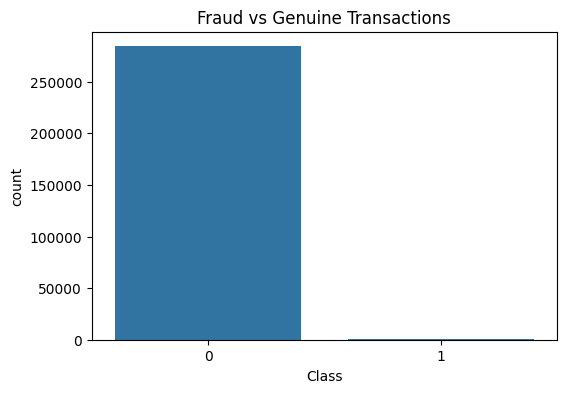

In [8]:
print("\nTransaction Counts")
print(df["Class"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

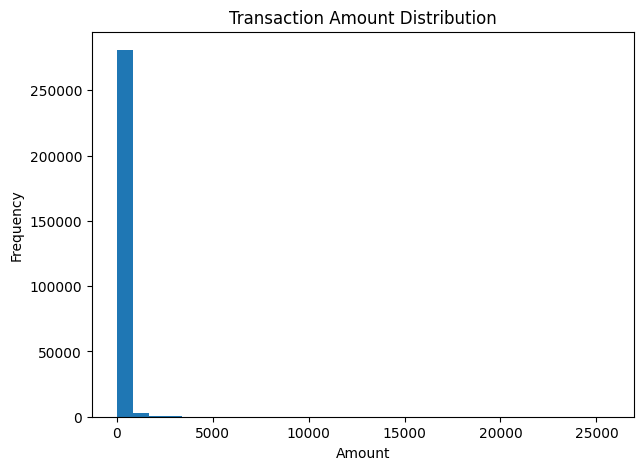

In [10]:
plt.figure(figsize=(7,5))
plt.hist(df["Amount"], bins=30)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

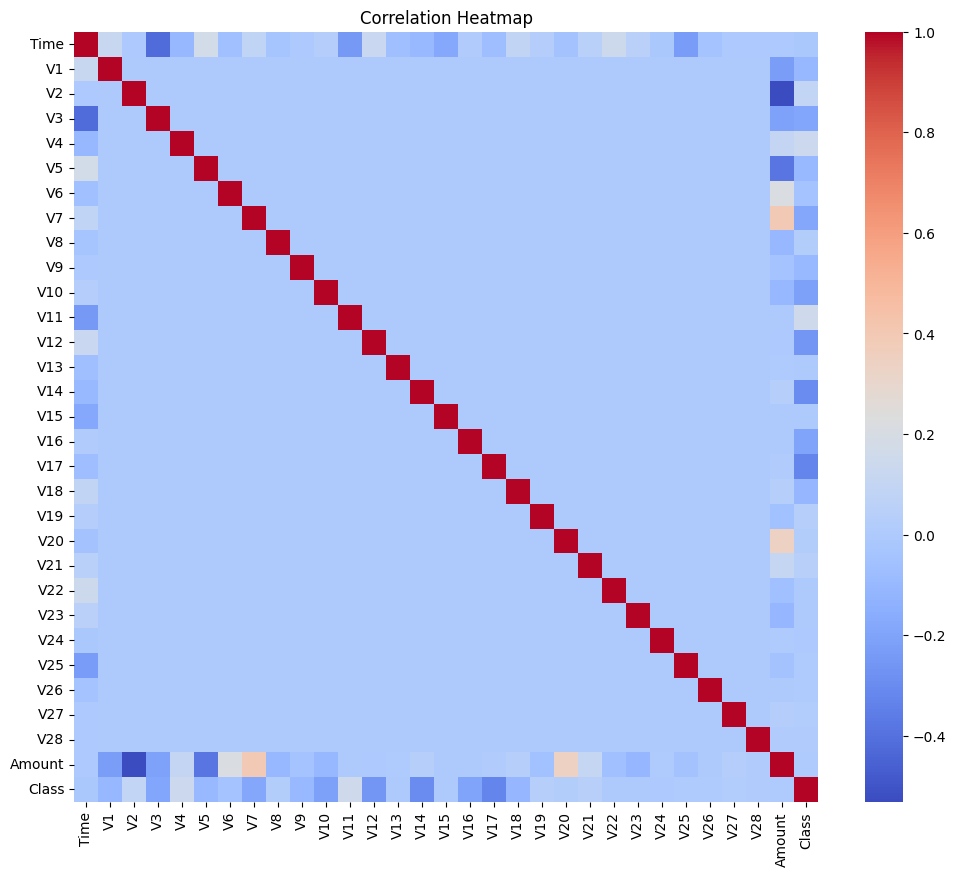

In [11]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [12]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [16]:
y_pred = model.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)


Accuracy: 0.9995962220427653



Confusion Matrix
[[56859     5]
 [   18    80]]


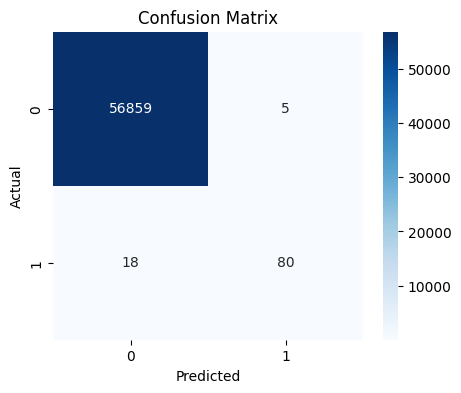

In [18]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
print("\nClassification Report")

print(classification_report(y_test, y_pred))


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [20]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

print("\nTop 10 Important Features")

print(importance.head(10))



Top 10 Important Features
V17    0.170325
V14    0.136363
V12    0.133326
V10    0.074073
V16    0.071792
V11    0.045277
V9     0.031127
V4     0.030496
V18    0.028156
V7     0.024627
dtype: float64


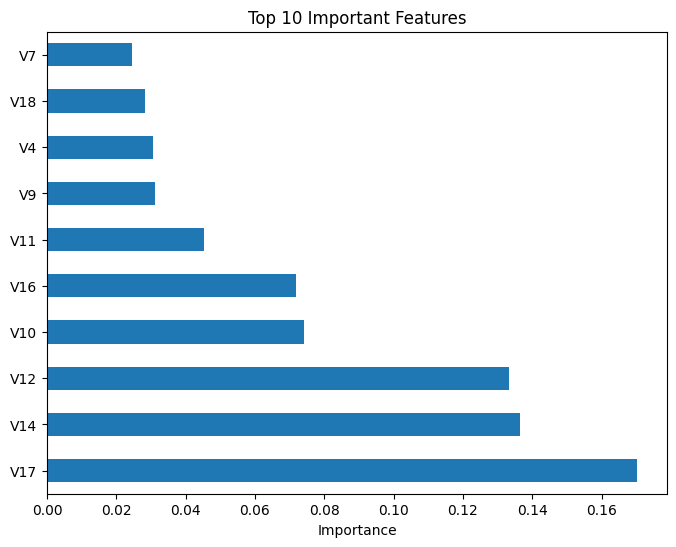

In [21]:
plt.figure(figsize=(8,6))

importance.head(10).plot(kind="barh")

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.show()


In [23]:
print("\n FRAUD INSIGHTS ")

print("Total Transactions :", len(df))

print("Fraud Transactions :", len(df[df["Class"] == 1]))

print("Genuine Transactions :", len(df[df["Class"] == 0]))

print("\nFraud Percentage : {:.4f}%".format(
    (len(df[df["Class"] == 1]) / len(df)) * 100
))

print("\nAverage Transaction Amount")

print(df["Amount"].mean())


 FRAUD INSIGHTS 
Total Transactions : 284807
Fraud Transactions : 492
Genuine Transactions : 284315

Fraud Percentage : 0.1727%

Average Transaction Amount
88.34961925093133
